# FCN for Devnagari Handwritten Digit Classification


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1: Data Preparation

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test"

IMG_SIZE = (28, 28)
NUM_CLASSES = 10

In [6]:
def load_images(folder):
    """Load images from folder, resize, normalize, and extract labels."""
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")          # grayscale
                img = img.resize(IMG_SIZE)                        # 28x28
                img_array = np.array(img) / 255.0                # normalize [0,1]
                images.append(img_array)
                labels.append(class_map[class_name])
            except Exception:
                pass

    return np.array(images), np.array(labels)

# Load data
x_train_raw, y_train_raw = load_images(train_dir)
x_test_raw,  y_test_raw  = load_images(test_dir)

# Flatten 28x28 → 784 for FCN input
x_train = x_train_raw.reshape(-1, 28 * 28)
x_test  = x_test_raw.reshape(-1, 28 * 28)

# One-hot encode labels
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f"Train: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test : {x_test.shape},  Labels: {y_test.shape}")

Train: (17000, 784), Labels: (17000, 10)
Test : (3000, 784),  Labels: (3000, 10)


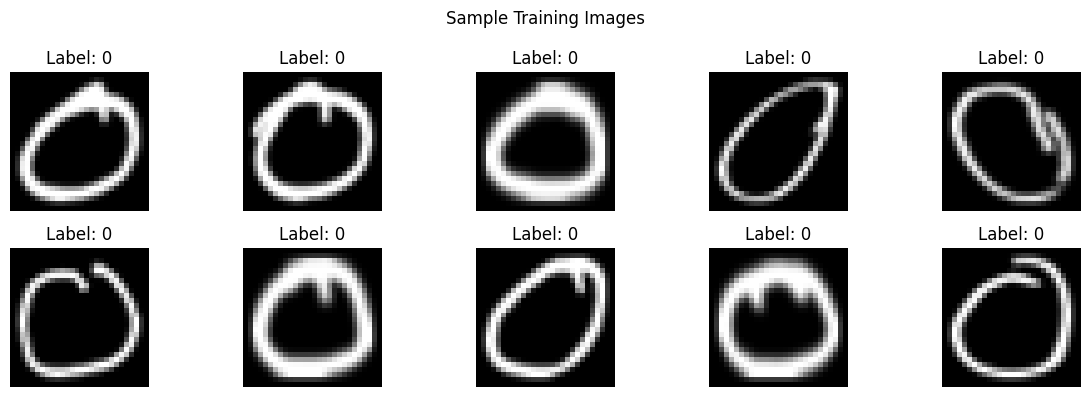

In [7]:
# Visualise sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation='relu'),   # 1st hidden layer
    keras.layers.Dense(128, activation='relu'),   # 2nd hidden layer
    keras.layers.Dense(256, activation='relu'),   # 3rd hidden layer
    keras.layers.Dense(NUM_CLASSES, activation='softmax')  # output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # labels are one-hot encoded
    metrics=['accuracy']
)

In [18]:
# Shuffle training data BEFORE fitting
from sklearn.utils import shuffle

x_train, y_train = shuffle(x_train, y_train, random_state=42)

## Task 4: Train the Model

In [19]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        verbose=1,
        restore_best_weights=True   # Fix #3
    )
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8948 - loss: 0.5984
Epoch 1: val_accuracy improved from None to 0.97471, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9411 - loss: 0.2509 - val_accuracy: 0.9747 - val_loss: 0.0869
Epoch 2/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9837 - loss: 0.0570
Epoch 2: val_accuracy improved from 0.97471 to 0.97794, saving model to best_devnagari_model.keras

Epoch 2: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9840 - loss: 0.0520 - val_accuracy: 0.9779 - val_loss: 0.0819
Epoch 3/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9897 - loss: 0.0323
Epoch 3: val_accuracy improved from 0.97794 to 0.98000, saving model to best_devnagari_model.keras

Epoch 3: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━

In [20]:

# Check label distributions
print("Train label unique values:", np.unique(y_train_raw))
print("Test  label unique values:", np.unique(y_test_raw))

# Check a few samples
print("\nTrain class_map:", {name: i for i, name in enumerate(sorted(os.listdir(train_dir)))})
print("Test  class_map:", {name: i for i, name in enumerate(sorted(os.listdir(test_dir)))})

Train label unique values: [0 1 2 3 4 5 6 7 8 9]
Test  label unique values: [0 1 2 3 4 5 6 7 8 9]

Train class_map: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Test  class_map: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}


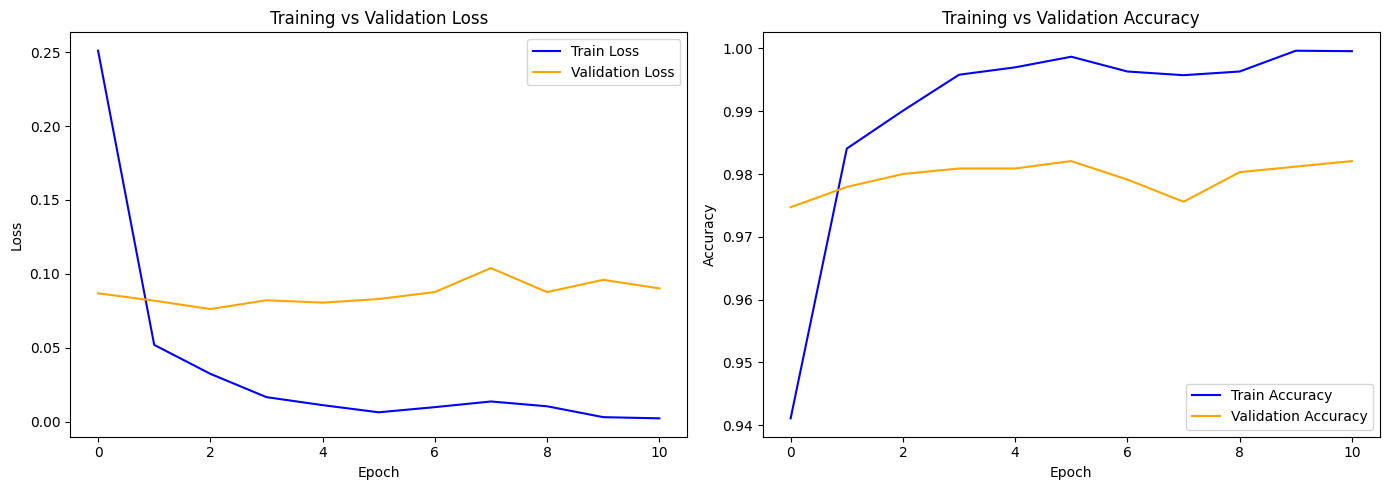

In [21]:
# Training & validation loss / accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [22]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

94/94 - 0s - 2ms/step - accuracy: 0.9810 - loss: 0.0735

Test Loss    : 0.0735
Test Accuracy: 0.9810 (98.10%)


## Task 6: Save and Load the Model

In [23]:
# Save model
model.save('devnagari_fcn_model.h5')
print("Model saved → devnagari_fcn_model.h5")

# Load model and re-evaluate
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model — Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved → devnagari_fcn_model.h5
94/94 - 1s - 5ms/step - accuracy: 0.9810 - loss: 0.0735

Loaded Model — Test Loss: 0.0735, Test Accuracy: 0.9810


## Task 7: Make Predictions

In [24]:
# Predict on test set
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f"Predicted: {predicted_labels[:10]}")
print(f"True     : {true_labels[:10]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
True     : [0 0 0 0 0 0 0 0 0 0]


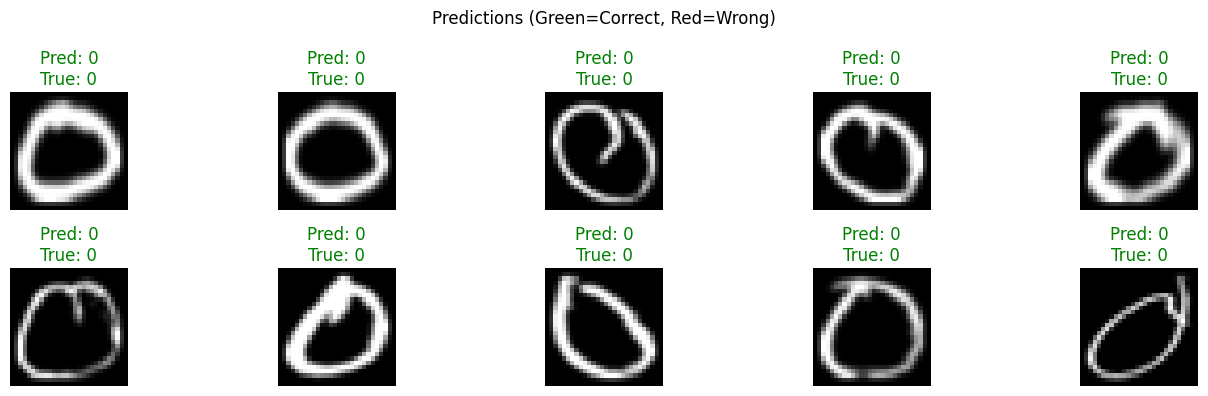

In [25]:
# Visualise predictions on 10 test samples
plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}", color=color)
    plt.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()